In [1]:
pip install -q git+https://github.com/amazon-science/chronos-forecasting.git


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from chronos import ChronosPipeline 
from datetime import datetime
import torch

from statsmodels.graphics.tsaplots import month_plot, quarter_plot, \
                                          plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, seasonal_mean

from sklearn.metrics import mean_absolute_error, mean_squared_error, \
                            root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid

/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-08 18:25:40.040877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741469140.122905    6808 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741469140.144738    6808 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-08 18:25:40.269568: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in perform

In [2]:
import tsdb

In [9]:
df = pd.DataFrame(tsdb.load('beijing_multisite_air_quality')['X'])
df.head()

2025-03-08 18:26:21 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2025-03-08 18:26:21 [INFO]: Dataset beijing_multisite_air_quality has already been downloaded. Processing directly...
2025-03-08 18:26:21 [INFO]: Dataset beijing_multisite_air_quality has already been cached. Loading from cache directly...
2025-03-08 18:26:21 [INFO]: Loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [10]:
df.rename(columns = {'TEMP': 'y'}, inplace = True)

<Axes: xlabel='ds'>

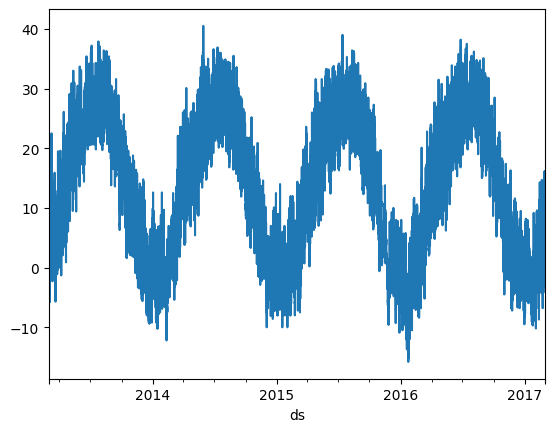

In [11]:
def clean_datetime(df):
    dttime = str(df['year']) + '-' + str(df['month']) + '-' + str(df['day']) + \
        ' ' + str(df['hour']) + ':00:00'
    
    return datetime.strptime(dttime, '%Y-%m-%d %H:%M:%S')

df['ds'] = df.apply(clean_datetime, axis = 1)

df.set_index('ds', inplace=True)
df = df.query('station == "Wanliu"')['y']
df = df.asfreq('h')


df.plot()

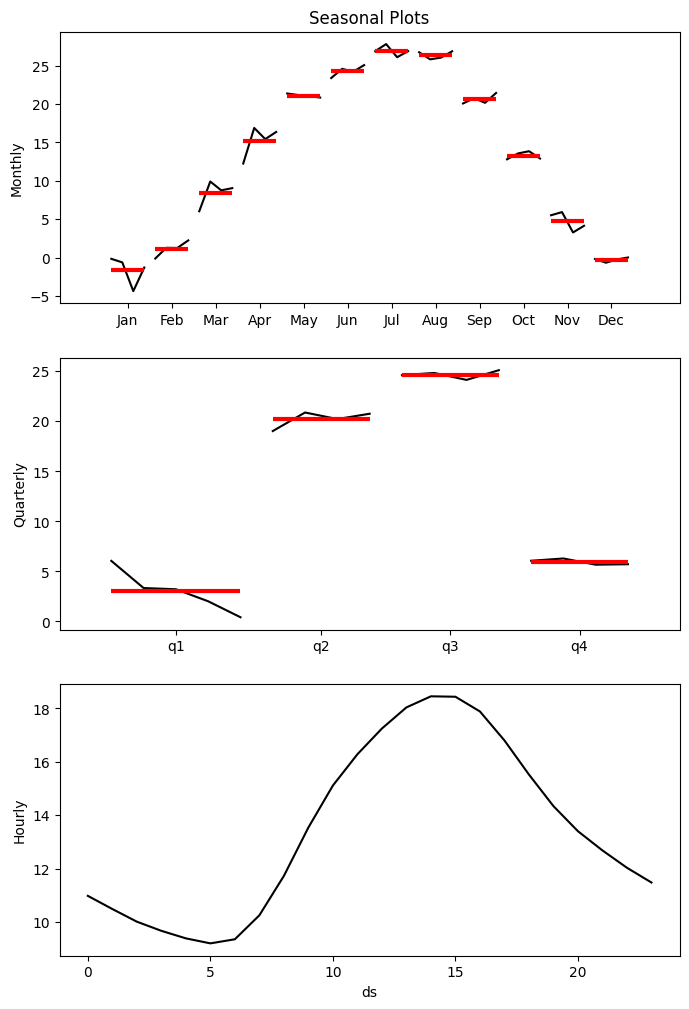

In [12]:
fig, ax = plt.subplots(3, 1, figsize = (8, 12))

month_plot(df.resample('ME').mean(),
           ylabel = 'Monthly',
           ax=ax[0])

quarter_plot(df.resample('QE').mean(),
             ylabel='Quarterly',
             ax = ax[1])

df.groupby(df.index.hour).mean().plot(ax=ax[2],
                                      color='black',
                                      ylabel='Hourly')

ax[0].set_title('Seasonal Plots')

plt.show()

In [13]:
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-base'
)

In [14]:
forecast = pipeline.predict(
    context = torch.tensor(df),
    temperature= 1.0,
    top_k = 50,
    top_p = 1.0,
    prediction_length = 72,
    num_samples = 20,
    limit_prediction_length = False
)

/tmp/ipykernel_6808/1689813843.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  context = torch.tensor(df),
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


In [15]:
forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim = 0)
forecast_mean

tensor([ 5.8922,  5.1178,  4.3098,  4.4108,  4.6128,  5.7912,  5.3872,  6.7003,
         8.5858, 11.2121, 12.8619, 14.4107, 14.9158, 16.0269, 16.1952, 15.7912,
        15.3535, 14.9158, 13.4343, 11.8855,  9.8990,  7.3064,  5.9932,  4.3098,
         2.9966,  1.9865,  1.2121,  0.7071, -0.5050, -1.1784, -1.4815, -0.7071,
         0.8081,  3.1986,  5.3872,  7.2054,  8.7879,  9.7979, 10.5387, 10.8080,
        10.2020,  8.8889,  7.6094,  5.3872,  3.6027,  4.0067,  2.8956,  3.2997,
         3.1986,  2.2896,  0.6061, -0.3030,  0.7071, -0.8081, -1.3131, -1.3468,
         1.2121,  3.2997,  4.0067,  4.4108,  4.8148,  5.6902,  5.9932,  5.9932,
        13.6450, 12.1374,  9.5863,  7.8082,  7.4989,  5.6822,  3.9814,  3.9041])

In [16]:
forecast_horizon = 72
stride = 48

start_date = df.index[-forecast_horizon * 10]
end_date = df.index[-1]

start_date, end_date

(Timestamp('2017-01-30 00:00:00'), Timestamp('2017-02-28 23:00:00'))

In [18]:
def time_series_cv(pipeline, df, forecast_horizon, stride, start_date, end_date):

    results = []

    current_date = start_date

    while current_date + pd.Timedelta(hours = forecast_horizon) <= end_date:

        train = df[df.index < current_date]
        test = df[current_date:current_date + pd.Timedelta(hours = forecast_horizon - 1)]

        forecast = pipeline.predict(context = torch.tensor(train.values),
                                    temperature = 1.0,
                                    top_k = 50,
                                    top_p = 1.0,
                                    prediction_length = 72,
                                    num_samples = 20,
                                    limit_prediction_length = False)
        
        forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim = 0)

        error = root_mean_squared_error(torch.tensor(test.values),
                                        forecast_mean)
        
        results.append((current_date, error))
        print(error)

        current_date += pd.Timedelta(hours = stride)

    return results

In [19]:
results = time_series_cv(pipeline,
                         df,
                         forecast_horizon,
                         stride,
                         start_date,
                         end_date)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


2.440183955338045


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


3.3540128009567614


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


...

2.6436991497674778


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


2.808031316962544


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


4.489795028094955
5.43376400859257


In [22]:
pd.DataFrame(results, columns = ['Date', 'RMSE'])

,Date,RMSE
0,2017-01-30,2.440184
1,2017-02-01,3.354013
2,2017-02-03,8.027487
3,2017-02-05,3.750720
4,2017-02-07,3.013084
5,2017-02-09,4.050628
6,2017-02-11,6.833804
7,2017-02-13,3.046423
8,2017-02-15,2.992884
9,2017-02-17,3.313337


Hyperparameter Tuning

In [23]:
import random

param_grid = {
    'temperature': [0.1, 0.5, 1.0, 1.5],
    'top_k': [10, 30, 50, 100],
    'top_p': [0.1, 0.5, 0.75, 1.0],
    'num_samples': [5, 10, 20, 50]
}

param_combinations = list(ParameterGrid(param_grid))

random.seed(42)
sampled_combinations = random.sample(param_combinations, 10)
sampled_combinations

[{'num_samples': 5, 'temperature': 1.5, 'top_k': 50, 'top_p': 0.5},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 100, 'top_p': 0.1},
 {'num_samples': 20, 'temperature': 0.1, 'top_k': 100, 'top_p': 0.1},
 {'num_samples': 10, 'temperature': 1.5, 'top_k': 100, 'top_p': 0.5},
 {'num_samples': 10, 'temperature': 1.5, 'top_k': 10, 'top_p': 0.75},
 {'num_samples': 10, 'temperature': 0.1, 'top_k': 30, 'top_p': 1.0},
 {'num_samples': 5, 'temperature': 1.5, 'top_k': 30, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 1.0, 'top_k': 100, 'top_p': 0.1},
 {'num_samples': 50, 'temperature': 0.5, 'top_k': 50, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 0.5, 'top_k': 10, 'top_p': 0.1}]

In [27]:
def time_series_cv_tuning(pipeline, df, forecast_horizon, stride, start_date, end_date, params):

    results = []
    all_predictions = []
    all_actuals = []

    current_date = start_date 

    while current_date + pd.Timedelta(hours = forecast_horizon) <= end_date:

        train = df[df.index < current_date]
        test = df[current_date:current_date + pd.Timedelta(hours = forecast_horizon - 1)]

        forecast = pipeline.predict(context = torch.tensor(train.values),
                                    temperature = params['temperature'],
                                    top_k = params['top_k'],
                                    top_p = params['top_p'],
                                    prediction_length = 72,
                                    num_samples = params['num_samples'],
                                    limit_prediction_length = False)
        
        forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim = 0)

        all_predictions.append(forecast_mean.numpy())
        all_actuals.append(torch.tensor(test.values).numpy())
        
        error = root_mean_squared_error(torch.tensor(test.values),
                                        forecast_mean)
        
        results.append((current_date, error))
        print(error)

        current_date += pd.Timedelta(hours = stride)

    return results, all_predictions, all_actuals

In [29]:
rmse_results = []

for params in sampled_combinations:
    results, _, _ = time_series_cv_tuning(pipeline,
                                        df,
                                        forecast_horizon,
                                        stride,
                                        start_date,
                                        end_date,
                                        params)

    mean_rmse = np.mean([error for _, error in results])
    rmse_results.append({**params, 'rmse': mean_rmse})

    print('\n\n\n\n\n\n\n' + str(params) + '\n\n\n\n\n\n\n' + str(mean_rmse) + '\n\n\n\n\n\n\n')


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


2.2382617915725693


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


4.105425743392797


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


...

2.925885997586372


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


3.1731671120512335


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


5.566838378083379
6.06831804265237







{'num_samples': 5, 'temperature': 0.5, 'top_k': 10, 'top_p': 0.1}






4.082468925304108









In [31]:
rmse_df = pd.DataFrame(rmse_results)
rmse_df

,num_samples,temperature,top_k,top_p,rmse
0,5,1.5,50,0.50,3.828611
1,5,0.1,100,0.10,4.089366
2,20,0.1,100,0.10,4.121889
3,10,1.5,100,0.50,3.882517
4,10,1.5,10,0.75,3.748440
5,10,0.1,30,1.00,4.007177
6,5,1.5,30,0.10,4.235408
7,5,1.0,100,0.10,4.007673
8,50,0.5,50,0.10,4.111180
9,5,0.5,10,0.10,4.082469


In [35]:
best_params = rmse_df.query('rmse == ' + str(rmse_df['rmse'].min()))
best_params_dict = best_params.iloc[:,:-1].squeeze().to_dict()

In [38]:

best_forecast = pipeline.predict(
    context = torch.tensor(df.values),
    temperature = best_params_dict['temperature'],
    top_k = int(best_params_dict['top_k']),
    top_p = int(best_params_dict['top_p']),
    prediction_length = forecast_horizon,
    num_samples = int(best_params_dict['num_samples']),
    limit_prediction_length = False)

best_forecast_mean = torch.mean(torch.stack([f[0] for f in best_forecast]), dim = 0)

forecast_index = pd.date_range(start = df.index[-1] + pd.Timedelta(hours = 1),
                               periods = forecast_horizon,
                               freq = 'h')

forecast_series = pd.Series(
    best_forecast_mean.numpy(),
    index = forecast_index)

forecast_series = forecast_series.rename('Amazon Chronos')

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


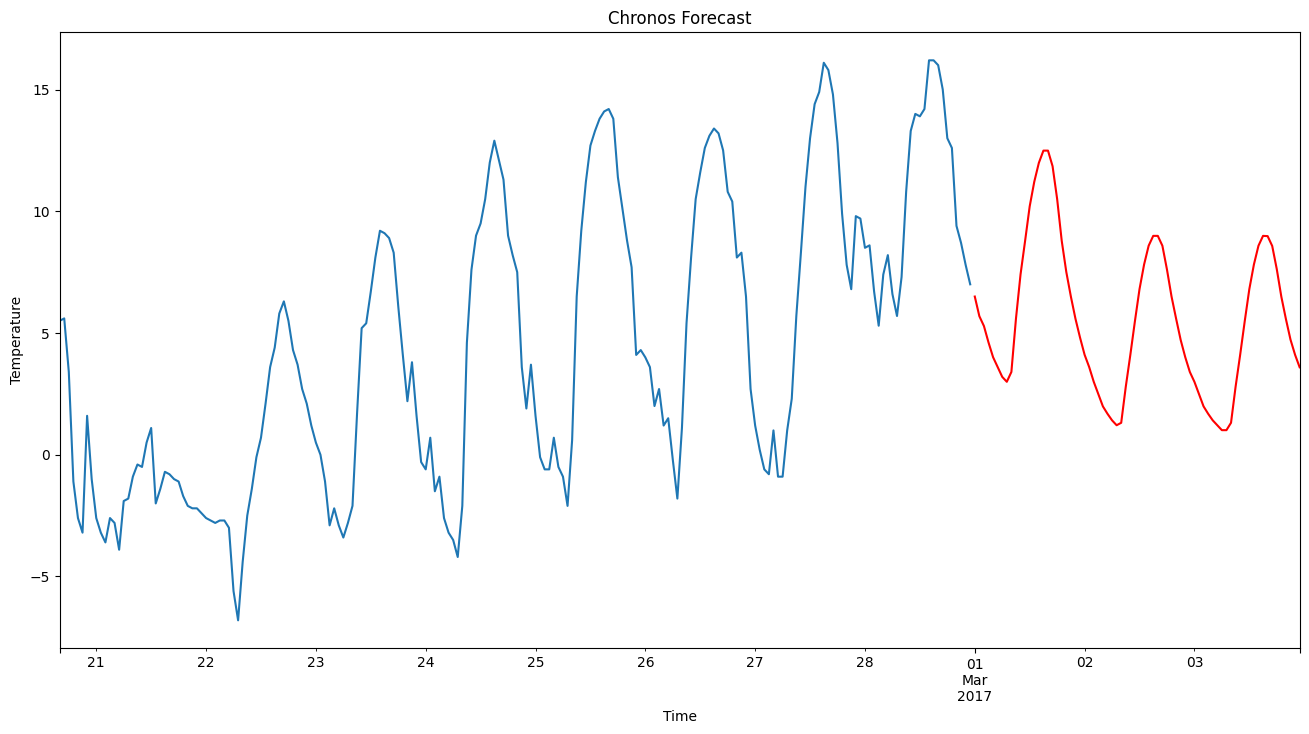

In [47]:
fig = plt.figure(figsize = (16, 8))
df[-200:].plot()
forecast_series.plot(color='red')

plt.title('Chronos Forecast')
plt.ylabel('Temperature')
plt.xlabel('Time')

plt.show()